<a href="https://colab.research.google.com/github/Amruth-U-tech/DL-Journey/blob/main/00-DataVisualisation/visualisation-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#hello there this is data visualisation practice where we go from preprocessing to visualizing
#lets import the data using pandas
import numpy as np
import pandas as pd

epstien = pd.read_csv("/content/drive/MyDrive/epstein-persons-2026-02-13_cleaned.csv")
epstien.head()

,Unnamed: 0,Name,Category,Bio,Aliases,Flights,Documents,Connections,In Black Book,Nationality
0,0,Ghislaine Maxwell,associate,Convicted sex trafficker; Epstein's closest as...,['G-Max'],413,900,123,True,British
1,1,Jeffrey Epstein,other,Convicted sex offender; financier; died in cus...,['Jeffrey Edward Epstein'],553,414,119,False,American
2,2,Sarah Kellen,associate,Epstein's primary scheduler; named co-conspira...,['Sarah Kellen Vickers'],364,23,74,True,American
3,3,Lesley Groff,associate,Epstein's executive assistant for two decades;...,[],92,19,36,True,American
4,4,Nadia Marcinkova,associate,Slovak-born Epstein associate brought to US as...,"['Nadia Marcinko', 'Global Girl']",140,9,33,True,Slovakian


In [3]:
#the above code was to check wether the dat taken is imported correctly or not
#no we move on to understand the data such as
print(epstien.shape) #checking how many datapoints X features we have
print(epstien.info())   #checking if all the col data types are correct or not

(1264, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1264 entries, 0 to 1263
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     1264 non-null   int64 
 1   Name           1264 non-null   object
 2   Category       1264 non-null   object
 3   Bio            1263 non-null   object
 4   Aliases        1264 non-null   object
 5   Flights        1264 non-null   int64 
 6   Documents      1264 non-null   int64 
 7   Connections    1264 non-null   int64 
 8   In Black Book  1264 non-null   bool  
 9   Nationality    521 non-null    object
dtypes: bool(1), int64(4), object(5)
memory usage: 90.2+ KB
None


In [4]:
print(epstien.isnull()) #checks wether therer are actually any missing values in whole data
print(epstien.isnull().sum()) #how many total values are missing from each cols

      Unnamed: 0   Name  Category    Bio  Aliases  Flights  Documents  \
0          False  False     False  False    False    False      False   
1          False  False     False  False    False    False      False   
2          False  False     False  False    False    False      False   
3          False  False     False  False    False    False      False   
4          False  False     False  False    False    False      False   
...          ...    ...       ...    ...      ...      ...        ...   
1259       False  False     False  False    False    False      False   
1260       False  False     False  False    False    False      False   
1261       False  False     False  False    False    False      False   
1262       False  False     False  False    False    False      False   
1263       False  False     False  False    False    False      False   

      Connections  In Black Book  Nationality  
0           False          False        False  
1           False          

from the above data inspection we see that most of them are not null and actually contains some value


but if u check the data actually alias col is almost fully empty and unnessay col

and as for the nationality we fill it with mode most repeated nation well thats plan

In [5]:
print(epstien.nunique()) #checks for unique values as in sql some cols must be unique
print(epstien.duplicated().sum())  #checks the no. of duplicates rows rowwise

#and by the output names must be unique and there is one name repeated no issues we will remove it

Unnamed: 0       1264
Name             1263
Category           10
Bio              1076
Aliases           209
Flights            31
Documents          23
Connections        27
In Black Book       2
Nationality        65
dtype: int64
0


now the whole inspection of the data is almost done to my knowledge

now what have we figured------------------------
1.   there are 10 features
2.   all the vlues are following the col data type
3.   there is one unnessay col
4.   there is some missing value that need ti be filled with some statergy
5.   some col are not following the uniqueness needs to be removed
6.   3 cols needs to be normalized(checked manually)

In [6]:
epstien_v = epstien.drop("Aliases",axis=1) #removes the unnaesary col and copys at the same time
epstien_v.fillna({"bio":"Bio not available","Nationality":"unknown"},inplace=True) #replacing the missing value with these
print(epstien_v.isnull().sum())  #checking if all the missing values is removed

#and as checked above that no two compplet row was repeated we assume for now everything is unique
#but where as the name has one repeated value but not full row is reapeated so we ignore just one value

Unnamed: 0       0
Name             0
Category         0
Bio              1
Flights          0
Documents        0
Connections      0
In Black Book    0
Nationality      0
dtype: int64


**data is now cleaned and preproccesed**

In [7]:
#checking that
epstien_v.head()

,Unnamed: 0,Name,Category,Bio,Flights,Documents,Connections,In Black Book,Nationality
0,0,Ghislaine Maxwell,associate,Convicted sex trafficker; Epstein's closest as...,413,900,123,True,British
1,1,Jeffrey Epstein,other,Convicted sex offender; financier; died in cus...,553,414,119,False,American
2,2,Sarah Kellen,associate,Epstein's primary scheduler; named co-conspira...,364,23,74,True,American
3,3,Lesley Groff,associate,Epstein's executive assistant for two decades;...,92,19,36,True,American
4,4,Nadia Marcinkova,associate,Slovak-born Epstein associate brought to US as...,140,9,33,True,Slovakian


before moving to visualising we do the next steps
0.  data integration (but we having no other file to integrate anything here)
1.  feature selection [which we already did as soon as we imported the data]
2.  feature engineering: it is where u add new cols based on the existing col such that u get few more extra and meaningful info

3.  once everything is done all we now need is get smth from the data either to visiaulise or train them
  4. and we do by data reduction which consistes of
      *   feature selection
      *   dimentionality reduction
      *   sampling


In [8]:
#feature selction done  and we dont need of dimentionalty reduction here we can do sampling
#first we do feature engneering
epstien_v["ConnectionLevel"] = pd.cut(epstien_v["Connections"],bins=[0,5,15,500],labels=["low","medium","high"])
epstien_v.head() #we added a feature engneering col if it cant fill a vlaue it will put NaN there try urself


,Unnamed: 0,Name,Category,Bio,Flights,Documents,Connections,In Black Book,Nationality,ConnectionLevel
0,0,Ghislaine Maxwell,associate,Convicted sex trafficker; Epstein's closest as...,413,900,123,True,British,high
1,1,Jeffrey Epstein,other,Convicted sex offender; financier; died in cus...,553,414,119,False,American,high
2,2,Sarah Kellen,associate,Epstein's primary scheduler; named co-conspira...,364,23,74,True,American,high
3,3,Lesley Groff,associate,Epstein's executive assistant for two decades;...,92,19,36,True,American,high
4,4,Nadia Marcinkova,associate,Slovak-born Epstein associate brought to US as...,140,9,33,True,Slovakian,high


In [9]:
#now all we need is normalisation hence
from sklearn import preprocessing
min_max_scaler = preprocessing.MinMaxScaler() #min max scaling
epstien_v[["Flights","Connections","Documents"]] = min_max_scaler.fit_transform(epstien_v[["Flights","Connections","Documents"]])

there is many other things we can do but for this data set this enough
**now we move to visualising**

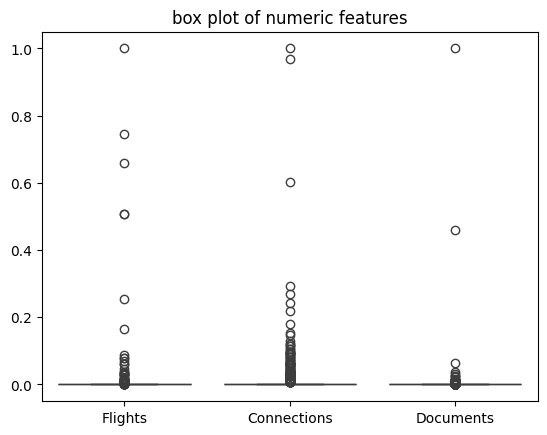

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

#first we do box plot to see if there is any outliers or smth
sns.boxplot(data=epstien_v[["Flights","Connections","Documents"]])
plt.title("box plot of numeric features")
plt.show()

Text(0, 0.5, 'documents')

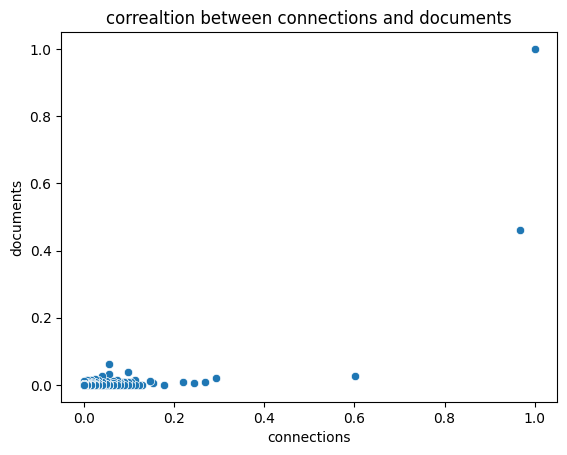

In [12]:
#now we do scatter plot between connections and documents to see if the investigation was legit
#x-sxis is connections and y-axis as documents

sns.scatterplot(data=epstien_v,x="Connections",y="Documents")

plt.title("correaltion between connections and documents")
plt.xlabel("connections")
plt.ylabel("documents")

Text(0, 0.5, 'noi. os individuals')

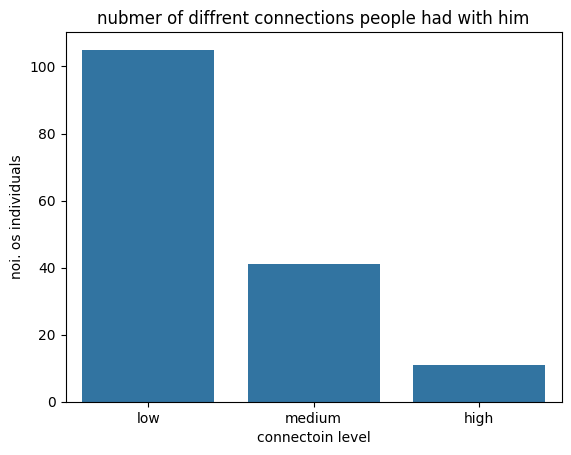

In [13]:
#having a count plot of how many low,mid and high connections were there to see how serious other peolpe weer about this
sns.countplot(data=epstien_v,x="ConnectionLevel")
plt.title("nubmer of diffrent connections people had with him")
plt.xlabel("connectoin level")
plt.ylabel("noi. os individuals")

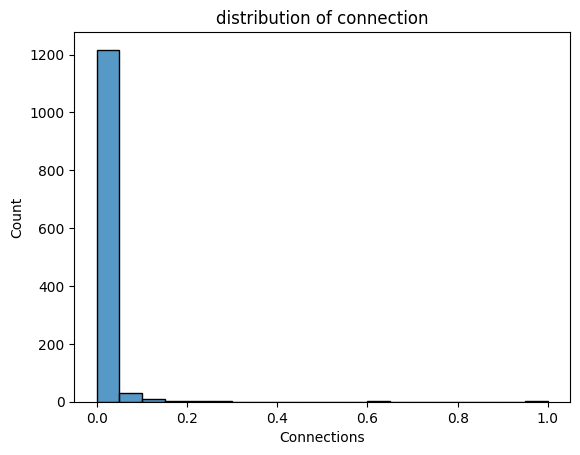

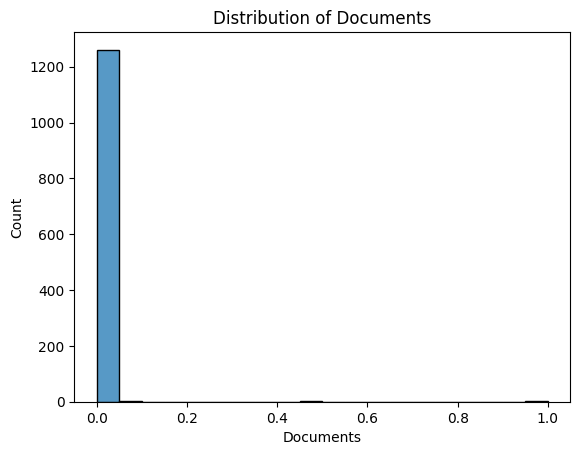

In [16]:
#histplot
sns.histplot(data=epstien_v,x="Connections",bins=20)
plt.title("distribution of connection")
plt.show()
sns.histplot(data=epstien_v, x="Documents", bins=20)

plt.title("Distribution of Documents")
plt.show()

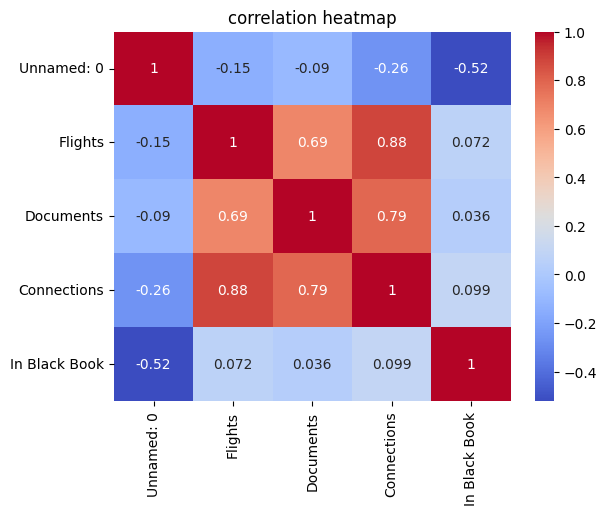

In [20]:
#heat maps which needs correlation and tell us th ecorrelatio between multiple data points at once
#corr_matrix = epstien_v[["Flights","Connections","Documents"]].corr()
corr_matrix = epstien_v.corr(numeric_only=True)
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm")
plt.title("correlation heatmap")
plt.show()